In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.dataset_2 import load_audio_dataset, load_lyrics, combine_features
from src.vae_2 import ConvVAE
from src.clustering_2 import run_kmeans, run_agglomerative, run_dbscan
from src.evaluation_2 import evaluate_clustering

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [4]:
import os

print(os.listdir("../data/audio"))

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [5]:
audio_X, labels = load_audio_dataset("../data/audio")

print(audio_X.shape)
print(len(labels))

Loaded 1
Loaded 2
Loaded 3
Loaded 4
Loaded 5
Loaded 6
Loaded 7
Loaded 8
Loaded 9
Loaded 10
Loaded 11
Loaded 12
Loaded 13
Loaded 14
Loaded 15
Loaded 16
Loaded 17
Loaded 18
Loaded 19
Loaded 20
Loaded 21
Loaded 22
Loaded 23
Loaded 24
Loaded 25
Loaded 26
Loaded 27
Loaded 28
Loaded 29
Loaded 30
Loaded 31
Loaded 32
Loaded 33
Loaded 34
Loaded 35
Loaded 36
Loaded 37
Loaded 38
Loaded 39
Loaded 40
Loaded 41
Loaded 42
Loaded 43
Loaded 44
Loaded 45
Loaded 46
Loaded 47
Loaded 48
Loaded 49
Loaded 50
(50, 1, 40, 130)
50


In [6]:
audio_X, labels = load_audio_dataset("../data/audio")

print(audio_X.shape)

Loaded 1
Loaded 2
Loaded 3
Loaded 4
Loaded 5
Loaded 6
Loaded 7
Loaded 8
Loaded 9
Loaded 10
Loaded 11
Loaded 12
Loaded 13
Loaded 14
Loaded 15
Loaded 16
Loaded 17
Loaded 18
Loaded 19
Loaded 20
Loaded 21
Loaded 22
Loaded 23
Loaded 24
Loaded 25
Loaded 26
Loaded 27
Loaded 28
Loaded 29
Loaded 30
Loaded 31
Loaded 32
Loaded 33
Loaded 34
Loaded 35
Loaded 36
Loaded 37
Loaded 38
Loaded 39
Loaded 40
Loaded 41
Loaded 42
Loaded 43
Loaded 44
Loaded 45
Loaded 46
Loaded 47
Loaded 48
Loaded 49
Loaded 50
(50, 1, 40, 130)


In [7]:
from torch.utils.data import DataLoader, TensorDataset
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(audio_X, dtype=torch.float32)

dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [8]:
model = ConvVAE(latent_dim=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
x = torch.randn(1, 1, 40, 130)

model = ConvVAE()
out = model.encoder(x)

print(out.shape)

torch.Size([1, 21120])


In [10]:
epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for batch in loader:
        x = batch[0].to(device)

        recon, mu, logvar, z = model(x)

     
        recon = recon[:, :, :x.shape[2], :x.shape[3]]

        # loss
        recon_loss = ((recon - x) ** 2).mean()
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        loss = recon_loss + kld

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 615805.6235351562
Epoch 2, Loss: 615043.3828125
Epoch 3, Loss: 615191.91015625
Epoch 4, Loss: 615342.0625
Epoch 5, Loss: 615617.154296875


In [11]:
model.eval()
latent_features = []

with torch.no_grad():
    for batch in loader:
        x = batch[0].to(device)

        _, _, _, z = model(x)
        latent_features.append(z.cpu().numpy())

latent_features = np.vstack(latent_features)

print("Latent shape:", latent_features.shape)

Latent shape: (50, 16)


In [13]:
lyrics_vec = load_lyrics("../data/lyrics/drake_lyrics.txt")

print("Lyrics shape:", lyrics_vec.shape)

Lyrics shape: (19366, 300)


In [14]:
combined_features = combine_features(latent_features, lyrics_vec)

print("Combined shape:", combined_features.shape)

Combined shape: (50, 316)


In [17]:
kmeans_labels = run_kmeans(combined_features, 10)
agg_labels = run_agglomerative(combined_features, 10)
dbscan_labels = run_dbscan(combined_features, eps=1.5)

print("Clustering done")

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Clustering done


In [18]:
print(type(kmeans_labels))

<class 'numpy.ndarray'>


In [19]:
kmeans_res = evaluate_clustering(combined_features, kmeans_labels, labels)
agg_res = evaluate_clustering(combined_features, agg_labels, labels)
dbscan_res = evaluate_clustering(combined_features, dbscan_labels, labels)

print("KMeans:", kmeans_res)
print("Agglomerative:", agg_res)
print("DBSCAN:", dbscan_res)

KMeans: {'silhouette': 0.24749804312213808, 'davies_bouldin': 0.7066296912367973, 'ARI': 0.0}
Agglomerative: {'silhouette': 0.30989639365917493, 'davies_bouldin': 0.6122006461478562, 'ARI': 0.0}
DBSCAN: {'silhouette': -1, 'davies_bouldin': -1, 'ARI': 1.0}


In [22]:
from src.evaluation_2 import save_results

In [24]:
import pandas as pd

results = {
    "KMeans": kmeans_res,
    "Agglomerative": agg_res,
    "DBSCAN": dbscan_res
}

df = pd.DataFrame(results).T

os.makedirs("../results", exist_ok=True)
df.to_csv("../results/clustering_metrics.csv")

print("Results saved!")
print(df)

Results saved!
               silhouette  davies_bouldin  ARI
KMeans           0.247498        0.706630  0.0
Agglomerative    0.309896        0.612201  0.0
DBSCAN          -1.000000       -1.000000  1.0


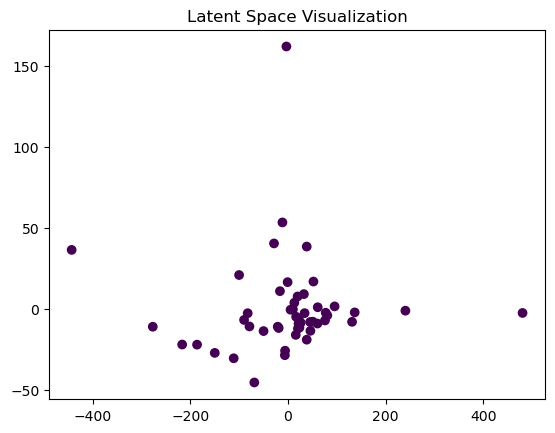

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(latent_features)

plt.scatter(reduced[:, 0], reduced[:, 1], c=labels)
plt.title("Latent Space Visualization")
plt.show()

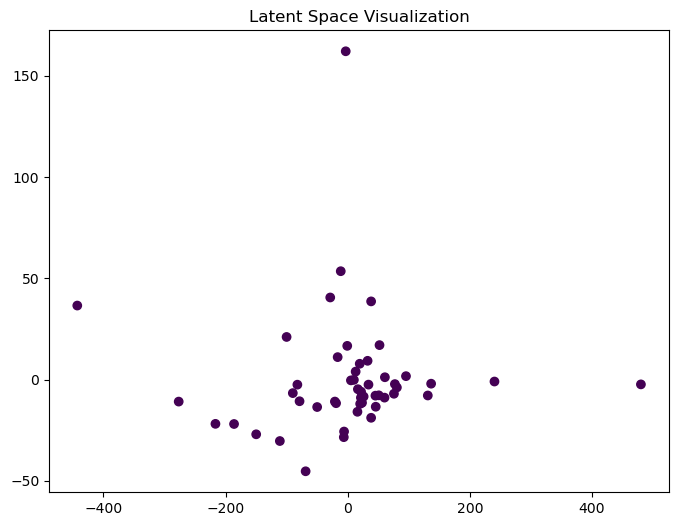

Plot saved in results/latent_visualization/


In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

# PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(latent_features)

# plot
plt.figure(figsize=(8,6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels)
plt.title("Latent Space Visualization")

os.makedirs("../results/latent_visualization", exist_ok=True)
plt.savefig("../results/latent_visualization/latent_plot.png")

plt.show()

print("Plot saved in results/latent_visualization/")

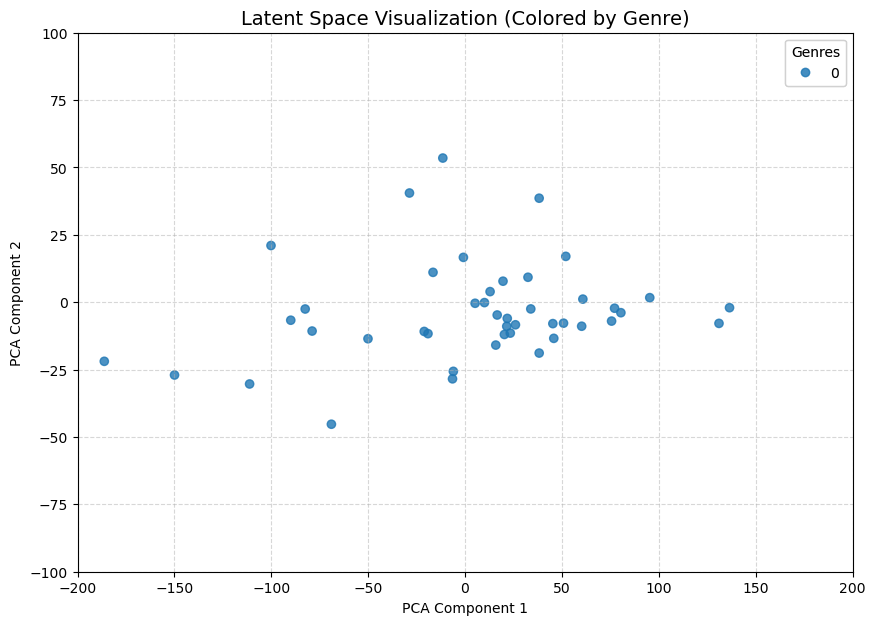

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

pca = PCA(n_components=2)
reduced = pca.fit_transform(latent_features)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=labels,
    cmap='tab10',
    alpha=0.8
)

plt.title("Latent Space Visualization (Colored by Genre)", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

legend = plt.legend(*scatter.legend_elements(), title="Genres")
plt.gca().add_artist(legend)

plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(-200, 200)
plt.ylim(-100, 100)

# save
os.makedirs("../results/latent_visualization", exist_ok=True)
plt.savefig("../results/latent_visualization/latent_plot_improved.png")

plt.show()

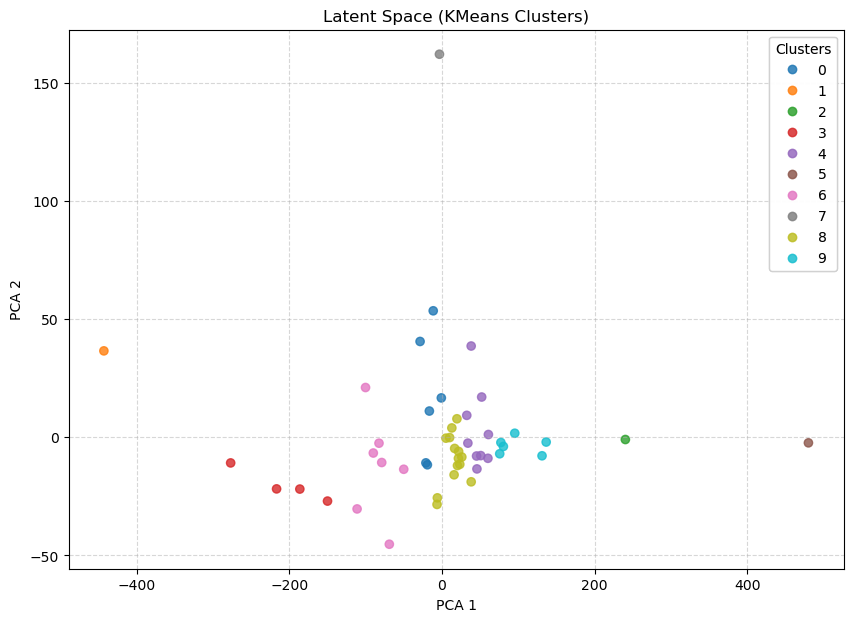

In [29]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=kmeans_labels,
    cmap='tab10',
    alpha=0.8
)

plt.title("Latent Space (KMeans Clusters)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend)

plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig("../results/latent_visualization/kmeans_clusters.png")
plt.show()

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


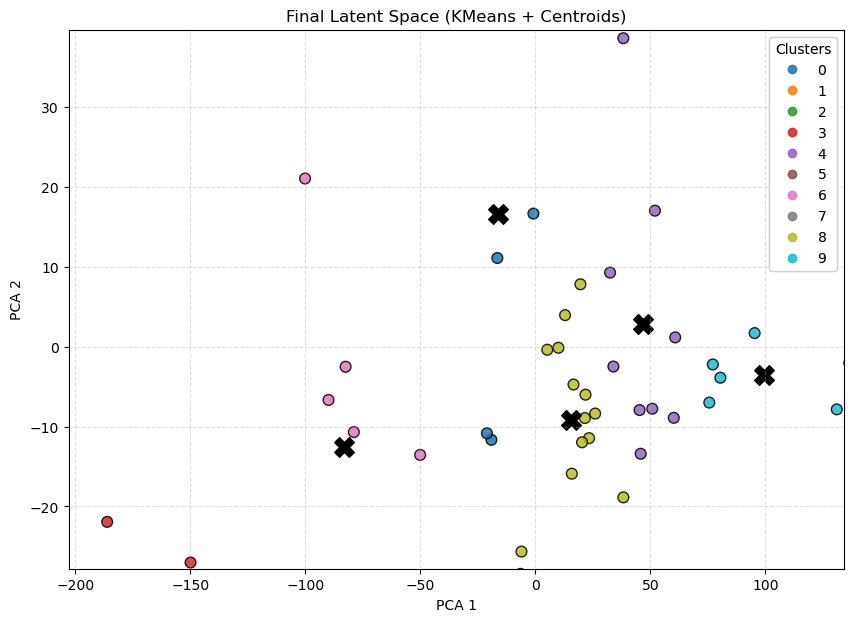

In [33]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

kmeans = KMeans(n_clusters=10, random_state=42)
kmeans_labels = kmeans.fit_predict(combined_features)

pca = PCA(n_components=2)
reduced = pca.fit_transform(combined_features)

centers = kmeans.cluster_centers_
centers_2d = pca.transform(centers)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=kmeans_labels,
    cmap='tab10',
    s=60,
    edgecolors='k',
    alpha=0.85
)

plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    c='black',
    s=200,
    marker='X',
    label='Centroids'
)

x_min, x_max = np.percentile(reduced[:,0], [5, 95])
y_min, y_max = np.percentile(reduced[:,1], [5, 95])

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.title("Final Latent Space (KMeans + Centroids)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend)

plt.grid(True, linestyle='--', alpha=0.4)

plt.savefig("../results/latent_visualization/final_plot.png")
plt.show()

In [35]:
from src.clustering_2 import run_kmeans
from src.evaluation_2 import evaluate_clustering

raw_features = audio_X.reshape(len(audio_X), -1)

print("Raw feature shape:", raw_features.shape)

kmeans_raw = run_kmeans(raw_features, 10)

baseline_res = evaluate_clustering(raw_features, kmeans_raw, labels)

print("\n BASELINE (RAW MFCC) ")
print(baseline_res)

print("\n VAE FEATURES ")
print("KMeans:", kmeans_res)

if baseline_res["silhouette"] < kmeans_res["silhouette"]:
    print("\n VAE improved clustering (higher silhouette score)")
else:
    print("\n VAE did not significantly improve clustering")

Raw feature shape: (50, 5200)

 BASELINE (RAW MFCC) 
{'silhouette': 0.06262693554162979, 'davies_bouldin': 1.4231113310989887, 'ARI': 0.0}

 VAE FEATURES 
KMeans: {'silhouette': 0.24749804312213808, 'davies_bouldin': 0.7066296912367973, 'ARI': 0.0}

 VAE improved clustering (higher silhouette score)


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


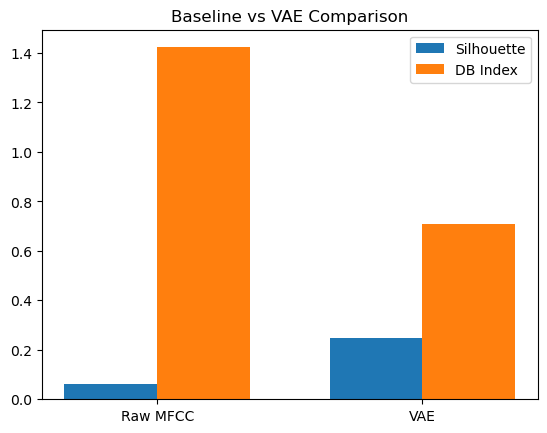

In [39]:
import numpy as np

x = np.arange(len(methods))
width = 0.35

plt.figure()

plt.bar(x - width/2, silhouette, width, label='Silhouette')
plt.bar(x + width/2, db_index, width, label='DB Index')

plt.xticks(x, methods)
plt.title("Baseline vs VAE Comparison")
plt.legend()

plt.savefig("../results/latent_visualization/comparison_combined.png")
plt.show()